# Step 3 Imputation of missing data
- Estimate missing values
- Reliability of imputed values 
- Outliers in the data

**Dataset 1 Trending Beauty Products**

Source: https://www.kaggle.com/datasets/waqi786/most-used-beauty-cosmetics-products-in-the-world/data

In [19]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns

In [2]:
beauty_products_data = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/beauty_products.csv')
not_cruelty_free_brands = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/brands_that_animal_test.csv')
cruelty_free_brands = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/cruelty_free_brands.csv')
toxic_chemicals_list = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/toxic_chemicals_in_products.csv')

In [3]:
beauty_products_data

,Product_Name,Brand,Category,Usage_Frequency,Price_USD,Rating,Number_of_Reviews,Product_Size,Skin_Type,Gender_Target,Packaging_Type,Main_Ingredient,Cruelty_Free,Country_of_Origin
0,Ultra Face Mask,Drunk Elephant,Blush,Weekly,67.85,1.4,686,30ml,Sensitive,Female,Tube,Retinol,False,Australia
1,Ultra Lipstick,Laura Mercier,Makeup Remover,Occasional,116.43,4.2,5483,250ml,Dry,Unisex,Bottle,Shea Butter,False,UK
2,Ultra Serum,Natasha Denona,Highlighter,Daily,90.84,1.6,5039,100ml,Sensitive,Male,Compact,Aloe Vera,True,Italy
3,Divine Serum,Ilia Beauty,Face Mask,Occasional,55.17,3.2,6202,250ml,Normal,Male,Tube,Glycerin,True,South Korea
4,Super Foundation,Charlotte Tilbury,Highlighter,Occasional,140.56,1.7,297,100ml,Oily,Female,Compact,Glycerin,False,Germany
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,Magic Eyeliner,Patrick Ta,Face Mask,Daily,131.64,2.8,1470,250ml,Sensitive,Unisex,Tube,Aloe Vera,True,Italy
14996,Perfect Powder,Farsali,Serum,Weekly,76.35,2.1,7652,250ml,Dry,Unisex,Jar,Salicylic Acid,True,USA
14997,Magic Serum,Kiehl’s,Highlighter,Occasional,65.37,4.2,811,30ml,Combination,Unisex,Jar,Shea Butter,False,South Korea
14998,Magic Mascara,Perricone MD,Powder,Weekly,59.93,4.8,5482,250ml,Dry,Male,Jar,Aloe Vera,True,USA


In [13]:
products_preview_table = beauty_products_data.head(5).style\
    .set_properties(**{
        'text-align': 'center',
        'padding': '10px 12px',
        'border-bottom': '1px solid #E6E1F0', 
        'font-family': 'sans-serif',
        'font-size': '12px',
        'color': '#2D2738' 
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#4A2E80'), 
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '12px'),
            ('border', 'none')
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', '#F8F6FC') 
        ]},
        {'selector': 'tbody', 'props': [
            ('border-bottom', '2px solid #4A2E80')
        ]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', 'bold'),
            ('color', '#4A2E80'),
            ('padding-bottom', '8px'),
            ('text-align', 'left')
        ]}
    ])\
    .set_caption("Table: Products Raw Data Preview")\
    .hide(axis='index')

products_preview_table
   

with open("products_preview_table.html", "w") as f:
    f.write(products_preview_table.to_html())

In [4]:
beauty_products_data.head()

,Product_Name,Brand,Category,Usage_Frequency,Price_USD,Rating,Number_of_Reviews,Product_Size,Skin_Type,Gender_Target,Packaging_Type,Main_Ingredient,Cruelty_Free,Country_of_Origin
0,Ultra Face Mask,Drunk Elephant,Blush,Weekly,67.85,1.4,686,30ml,Sensitive,Female,Tube,Retinol,False,Australia
1,Ultra Lipstick,Laura Mercier,Makeup Remover,Occasional,116.43,4.2,5483,250ml,Dry,Unisex,Bottle,Shea Butter,False,UK
2,Ultra Serum,Natasha Denona,Highlighter,Daily,90.84,1.6,5039,100ml,Sensitive,Male,Compact,Aloe Vera,True,Italy
3,Divine Serum,Ilia Beauty,Face Mask,Occasional,55.17,3.2,6202,250ml,Normal,Male,Tube,Glycerin,True,South Korea
4,Super Foundation,Charlotte Tilbury,Highlighter,Occasional,140.56,1.7,297,100ml,Oily,Female,Compact,Glycerin,False,Germany


**Describe the Data**
- Checking numerical fields
- Checking for unique brand names

In [5]:
summary = beauty_products_data.describe()
print(summary)

          Price_USD        Rating  Number_of_Reviews
count  15000.000000  15000.000000       15000.000000
mean      80.134108      3.002327        5014.231333
std       40.402983      1.168029        2855.665464
min       10.000000      1.000000          52.000000
25%       45.480000      2.000000        2562.000000
50%       80.040000      3.000000        5002.000000
75%      114.760000      4.000000        7497.000000
max      149.990000      5.000000       10000.000000


In [6]:
print("Product Name" + beauty_products_data.Product_Name.unique())

['Product NameUltra Face Mask' 'Product NameUltra Lipstick'
 'Product NameUltra Serum' 'Product NameDivine Serum'
 'Product NameSuper Foundation' 'Product NameSuper Eye Shadow'
 'Product NameSuper Lip Gloss' 'Product NameUltra Cleanser'
 'Product NameMagic Highlighter' 'Product NamePerfect Bronzer'
 'Product NameUltra Moisturizer' 'Product NameDivine CC Cream'
 'Product NameUltra Setting Spray' 'Product NameDivine Primer'
 'Product NameDivine Exfoliator' 'Product NamePerfect Blush'
 'Product NamePerfect Highlighter' 'Product NameSuper Cleanser'
 'Product NameUltra Face Oil' 'Product NameDivine Lip Gloss'
 'Product NameDivine Foundation' 'Product NameDivine Cleanser'
 'Product NamePerfect Eyeliner' 'Product NameSuper Serum'
 'Product NameDivine Setting Spray' 'Product NameMagic Eye Shadow'
 'Product NameUltra Exfoliator' 'Product NameMagic Lip Liner'
 'Product NameSuper Makeup Remover' 'Product NamePerfect BB Cream'
 'Product NameMagic BB Cream' 'Product NameSuper Lip Liner'
 'Product N

In [7]:
print("Brand Name" + beauty_products_data.Brand.unique())


['Brand NameDrunk Elephant' 'Brand NameLaura Mercier'
 'Brand NameNatasha Denona' 'Brand NameIlia Beauty'
 'Brand NameCharlotte Tilbury' 'Brand NameDanessa Myricks'
 'Brand NameBourjois' 'Brand NameIT Cosmetics' 'Brand NameFenty Beauty'
 'Brand NameSisley' 'Brand NameJuvia’s Place' 'Brand NameNARS'
 'Brand NameColourPop' 'Brand NameHuda Beauty' 'Brand NameTatcha'
 'Brand NameKiehl’s' 'Brand NameTarte' 'Brand NameGlossier'
 'Brand NameMake Up For Ever' 'Brand NameAnastasia Beverly Hills'
 'Brand NameE.l.f.' 'Brand NameHourglass' 'Brand NamePat McGrath Labs'
 'Brand NameToo Faced' 'Brand NamePerricone MD' 'Brand NameRMS Beauty'
 'Brand NameUrban Decay' 'Brand NameRare Beauty' 'Brand NameBecca'
 'Brand NamePatrick Ta' 'Brand NameShiseido' 'Brand NameKylie Cosmetics'
 'Brand NameBite Beauty' 'Brand NameYves Saint Laurent'
 'Brand NameBobby Brown' 'Brand NameFarsali' 'Brand NameMorphe'
 'Brand NameMilk Makeup' 'Brand NameClinique' 'Brand NameKVD Beauty']


**Check if there are any missing values in Dataset 1**

There are no missing values in Dataset1

In [8]:
print(beauty_products_data.isnull().sum())

Product_Name         0
Brand                0
Category             0
Usage_Frequency      0
Price_USD            0
Rating               0
Number_of_Reviews    0
Product_Size         0
Skin_Type            0
Gender_Target        0
Packaging_Type       0
Main_Ingredient      0
Cruelty_Free         0
Country_of_Origin    0
dtype: int64


**Check for outliers in Dataset 1 for numerical variables**

**Price**

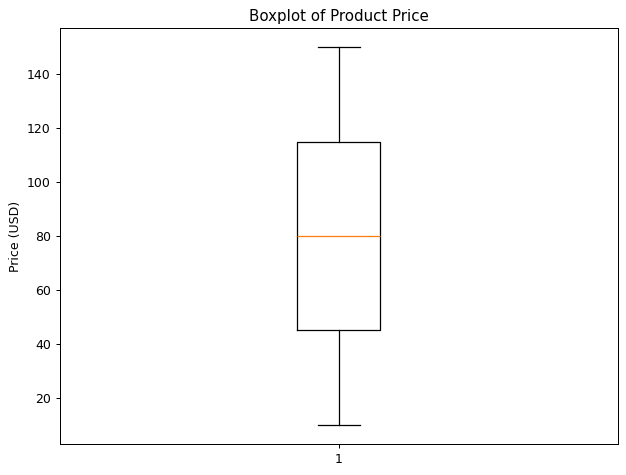

In [9]:
figure(num=None, figsize=(8,6), dpi= 90, facecolor= 'w', edgecolor = 'k')
plt.boxplot(beauty_products_data.Price_USD)
plt.title("Boxplot of Product Price")
plt.ylabel("Price (USD)")
plt.show()

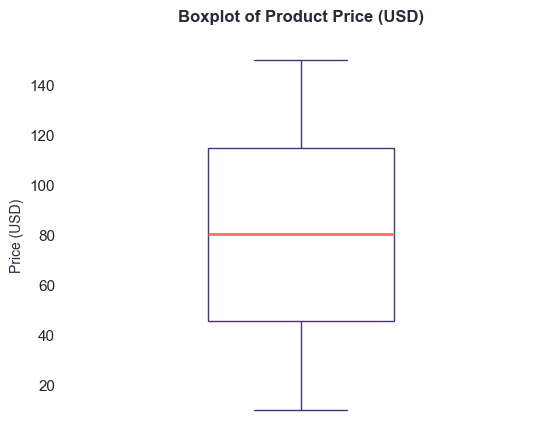

In [27]:
plt.figure(figsize=(6, 5))
sns.set_theme(style="white")

sns.boxplot(
    y='Price_USD', 
    data=beauty_products_data, 
    color='white',  
    width=0.4,
    fliersize=5,
    boxprops=dict(edgecolor='#4A2E80'), 
    whiskerprops=dict(color='#4A2E80'),
    capprops=dict(color='#4A2E80'),
    medianprops=dict(color='#FF6B6B', linewidth=2) 
)

plt.title('Boxplot of Product Price (USD)', pad=15, fontsize=12, weight='bold', color='#2D2738')
plt.ylabel('Price (USD)', fontsize=10, color='#2D2738')
sns.despine(left=True, bottom=True)

plt.savefig('price_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

**Number of Reviews**

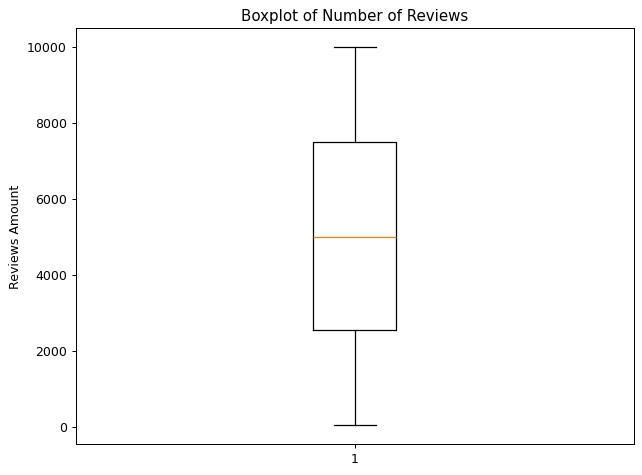

In [10]:
figure(num=None, figsize=(8,6), dpi= 90, facecolor= 'w', edgecolor = 'k')
plt.boxplot(beauty_products_data.Number_of_Reviews)
plt.title("Boxplot of Number of Reviews")
plt.ylabel("Reviews Amount")
plt.show()

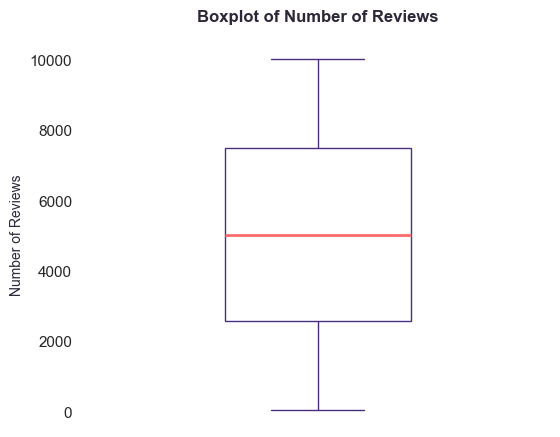

In [29]:
plt.figure(figsize=(6, 5))
sns.set_theme(style="white")

sns.boxplot(
    y='Number_of_Reviews', 
    data=beauty_products_data, 
    color='white',  
    width=0.4,
    fliersize=5,
    boxprops=dict(edgecolor='#4A2E80'), 
    whiskerprops=dict(color='#4A2E80'),
    capprops=dict(color='#4A2E80'),
    medianprops=dict(color='#FF6B6B', linewidth=2) 
)

plt.title('Boxplot of Number of Reviews', pad=15, fontsize=12, weight='bold', color='#2D2738')
plt.ylabel('Number of Reviews', fontsize=10, color='#2D2738')
sns.despine(left=True, bottom=True)

plt.savefig('price_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

Don't need to check for missing values for datasets 2 and 3 

In [11]:
not_cruelty_free_brands

,Unnamed: 0,Brand Name
0,0,Acuvue (Johnson & Johnson)
1,1,Aim (Church & Dwight)
2,2,Air Wick (Reckitt Benckiser)
3,3,Algenist
4,4,Always (Procter & Gamble)
...,...,...
265,265,Windex (S.C. Johnson)
266,266,Woolite (Reckitt Benckiser)
267,267,Xtra (Church & Dwight)
268,268,Zegna


In [12]:
cruelty_free_brands

,Unnamed: 0,Brand Name
0,0,A Good Fur Day
1,1,A.P. CHEM
2,2,A Perfume Organic
3,3,A Touch of Class Beauty
4,4,A Wild Soap Bar
...,...,...
6323,6323,Zoygirl (Zoycare Hygiene)
6324,6324,Zue Beauty
6325,6325,Zuii Organic
6326,6326,Zuzu Cosmetics


**Dataset 4 Toxic Chemicals List**

In [13]:
toxic_chemicals_list

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,CasNumber,ChemicalId,ChemicalName,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,...,13463-67-7,6,Titanium dioxide,6/17/2009,8/28/2013,2/1/2011,7/9/2009,7/9/2009,NaN,1
1,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,65996-92-1,4,Distillates (coal tar),7/1/2009,7/1/2009,NaN,7/1/2009,7/1/2009,NaN,2
2,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,140-67-0,5,Estragole,7/1/2009,7/1/2009,NaN,7/2/2009,7/2/2009,NaN,2
3,4,PRECISION GLIMMER EYE LINER-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,...,13463-67-7,7,Titanium dioxide,7/9/2009,8/28/2013,NaN,7/9/2009,7/9/2009,NaN,1
4,5,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,...,13463-67-7,8,Titanium dioxide,7/9/2009,8/28/2013,2/1/2011,7/9/2009,7/9/2009,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114630,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65001.0,Rosa Soft,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68059,Titanium dioxide,6/19/2020,6/19/2020,NaN,6/19/2020,6/19/2020,NaN,1
114631,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65002.0,Malva Spirit,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68060,Titanium dioxide,6/19/2020,6/19/2020,NaN,6/19/2020,6/19/2020,NaN,1
114632,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65003.0,Rojo Fashion,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68061,Titanium dioxide,6/19/2020,6/19/2020,NaN,6/19/2020,6/19/2020,NaN,1
114633,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65004.0,Terra Mystic,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68062,Titanium dioxide,6/19/2020,6/19/2020,NaN,6/19/2020,6/19/2020,NaN,1


In [14]:
print(beauty_products_data.isnull().sum())

Product_Name         0
Brand                0
Category             0
Usage_Frequency      0
Price_USD            0
Rating               0
Number_of_Reviews    0
Product_Size         0
Skin_Type            0
Gender_Target        0
Packaging_Type       0
Main_Ingredient      0
Cruelty_Free         0
Country_of_Origin    0
dtype: int64


In [15]:
uncaught_null_values = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/toxic_chemicals_in_products.csv', na_values=['N/A', 'n/a', 'NA', 'Missing value'])

print(uncaught_null_values[['CSFId', 'CSF', 'DiscontinuedDate', 'ChemicalDateRemoved']].isnull().sum())

CSFId                   33973
CSF                     34398
DiscontinuedDate       101715
ChemicalDateRemoved    111650
dtype: int64


Found uncaught missing values in the dataset
- Giving the CSFId variable missing values a new value of 0, as the Id requires to be given by the America government. 
- Giving CSF a value of "Standard" as this field includes the specific ingredients, and I am unsure of what they are for the missing values. 
- Changing missing values for Discontinued dates to "Not discontinued" as this means the product can still be purchased, the same for the variable Chemical Date Removed.


In [16]:
uncaught_null_values['CSFId'] = uncaught_null_values['CSFId'].fillna(0)
uncaught_null_values['CSF'] = uncaught_null_values['CSFId'].fillna('Standard')
uncaught_null_values['DiscontinuedDate'] = uncaught_null_values['DiscontinuedDate'].fillna('Not Discontinued')
uncaught_null_values['ChemicalDateRemoved'] = uncaught_null_values['ChemicalDateRemoved'].fillna('Still Present')

print(uncaught_null_values[['CSFId', 'CSF', 'DiscontinuedDate', 'ChemicalDateRemoved']].isnull().sum())


CSFId                  0
CSF                    0
DiscontinuedDate       0
ChemicalDateRemoved    0
dtype: int64


In [17]:
new_toxic_chemicals_list = uncaught_null_values.to_csv('clean_toxic_chemicals_list.csv', index=False)

**Join Datasets Together**

In [18]:
products = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/beauty_products.csv')
# Linking datasets based on the common variable Brand Names
cruelty_free = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/cruelty_free_brands.csv').drop_duplicates(subset=['Brand Name'])
not_cruelty_free = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/brands_that_animal_test.csv').drop_duplicates(subset=['Brand Name'])

In [19]:
# Adding context to each list as it is currently a list of brand names for each dataset 
cruelty_free['PETA_Status'] = 'Certified Cruelty Free'
not_cruelty_free['PETA_Status'] = 'Tests on Animals'

In [20]:
# Combine the two datasets, final dataset will include the brand name and the PETA status ('Certified Cruelty Free' or 'Tests on Animals')
peta_list = pd.concat([cruelty_free, not_cruelty_free], ignore_index=True)

In [21]:
peta_list

,Unnamed: 0,Brand Name,PETA_Status
0,0,A Good Fur Day,Certified Cruelty Free
1,1,A.P. CHEM,Certified Cruelty Free
2,2,A Perfume Organic,Certified Cruelty Free
3,3,A Touch of Class Beauty,Certified Cruelty Free
4,4,A Wild Soap Bar,Certified Cruelty Free
...,...,...,...
6584,265,Windex (S.C. Johnson),Tests on Animals
6585,266,Woolite (Reckitt Benckiser),Tests on Animals
6586,267,Xtra (Church & Dwight),Tests on Animals
6587,268,Zegna,Tests on Animals


In [22]:
# Toxic chemicals list cleaned
new_toxic_chemicals_list = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/clean_toxic_chemicals_list.csv').drop_duplicates(subset=['ChemicalName'])

In [23]:
dataset_with_cruelty_free_list = pd.merge(
    products, 
    peta_list, 
    left_on='Brand', 
    right_on= 'Brand Name', 
    how= 'left'
)

dataset_with_cruelty_free_list.drop(columns=['Brand Name'], errors='ignore', inplace=True)

In [24]:
dataset_with_cruelty_free_list

,Product_Name,Brand,Category,Usage_Frequency,Price_USD,Rating,Number_of_Reviews,Product_Size,Skin_Type,Gender_Target,Packaging_Type,Main_Ingredient,Cruelty_Free,Country_of_Origin,Unnamed: 0,PETA_Status
0,Ultra Face Mask,Drunk Elephant,Blush,Weekly,67.85,1.4,686,30ml,Sensitive,Female,Tube,Retinol,False,Australia,1666.0,Certified Cruelty Free
1,Ultra Lipstick,Laura Mercier,Makeup Remover,Occasional,116.43,4.2,5483,250ml,Dry,Unisex,Bottle,Shea Butter,False,UK,NaN,NaN
2,Ultra Serum,Natasha Denona,Highlighter,Daily,90.84,1.6,5039,100ml,Sensitive,Male,Compact,Aloe Vera,True,Italy,NaN,NaN
3,Divine Serum,Ilia Beauty,Face Mask,Occasional,55.17,3.2,6202,250ml,Normal,Male,Tube,Glycerin,True,South Korea,NaN,NaN
4,Super Foundation,Charlotte Tilbury,Highlighter,Occasional,140.56,1.7,297,100ml,Oily,Female,Compact,Glycerin,False,Germany,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,Magic Eyeliner,Patrick Ta,Face Mask,Daily,131.64,2.8,1470,250ml,Sensitive,Unisex,Tube,Aloe Vera,True,Italy,NaN,NaN
14996,Perfect Powder,Farsali,Serum,Weekly,76.35,2.1,7652,250ml,Dry,Unisex,Jar,Salicylic Acid,True,USA,NaN,NaN
14997,Magic Serum,Kiehl’s,Highlighter,Occasional,65.37,4.2,811,30ml,Combination,Unisex,Jar,Shea Butter,False,South Korea,NaN,NaN
14998,Magic Mascara,Perricone MD,Powder,Weekly,59.93,4.8,5482,250ml,Dry,Male,Jar,Aloe Vera,True,USA,NaN,NaN


Adding Toxic Chemical List to Products Dataset

In [25]:
final_dataset = pd.merge(
    dataset_with_cruelty_free_list, 
    new_toxic_chemicals_list[['ChemicalName', 'DiscontinuedDate', 'ChemicalDateRemoved']], 
    left_on='Main_Ingredient', 
    right_on='ChemicalName', 
    how='left'
)

final_dataset.drop(columns=['ChemicalName'], errors='ignore', inplace=True)

In [26]:
final_dataset

,Product_Name,Brand,Category,Usage_Frequency,Price_USD,Rating,Number_of_Reviews,Product_Size,Skin_Type,Gender_Target,Packaging_Type,Main_Ingredient,Cruelty_Free,Country_of_Origin,Unnamed: 0,PETA_Status,DiscontinuedDate,ChemicalDateRemoved
0,Ultra Face Mask,Drunk Elephant,Blush,Weekly,67.85,1.4,686,30ml,Sensitive,Female,Tube,Retinol,False,Australia,1666.0,Certified Cruelty Free,Not Discontinued,Still Present
1,Ultra Lipstick,Laura Mercier,Makeup Remover,Occasional,116.43,4.2,5483,250ml,Dry,Unisex,Bottle,Shea Butter,False,UK,NaN,NaN,NaN,NaN
2,Ultra Serum,Natasha Denona,Highlighter,Daily,90.84,1.6,5039,100ml,Sensitive,Male,Compact,Aloe Vera,True,Italy,NaN,NaN,NaN,NaN
3,Divine Serum,Ilia Beauty,Face Mask,Occasional,55.17,3.2,6202,250ml,Normal,Male,Tube,Glycerin,True,South Korea,NaN,NaN,NaN,NaN
4,Super Foundation,Charlotte Tilbury,Highlighter,Occasional,140.56,1.7,297,100ml,Oily,Female,Compact,Glycerin,False,Germany,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,Magic Eyeliner,Patrick Ta,Face Mask,Daily,131.64,2.8,1470,250ml,Sensitive,Unisex,Tube,Aloe Vera,True,Italy,NaN,NaN,NaN,NaN
14996,Perfect Powder,Farsali,Serum,Weekly,76.35,2.1,7652,250ml,Dry,Unisex,Jar,Salicylic Acid,True,USA,NaN,NaN,NaN,NaN
14997,Magic Serum,Kiehl’s,Highlighter,Occasional,65.37,4.2,811,30ml,Combination,Unisex,Jar,Shea Butter,False,South Korea,NaN,NaN,NaN,NaN
14998,Magic Mascara,Perricone MD,Powder,Weekly,59.93,4.8,5482,250ml,Dry,Male,Jar,Aloe Vera,True,USA,NaN,NaN,NaN,NaN


In [27]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product_Name         15000 non-null  object 
 1   Brand                15000 non-null  object 
 2   Category             15000 non-null  object 
 3   Usage_Frequency      15000 non-null  object 
 4   Price_USD            15000 non-null  float64
 5   Rating               15000 non-null  float64
 6   Number_of_Reviews    15000 non-null  int64  
 7   Product_Size         15000 non-null  object 
 8   Skin_Type            15000 non-null  object 
 9   Gender_Target        15000 non-null  object 
 10  Packaging_Type       15000 non-null  object 
 11  Main_Ingredient      15000 non-null  object 
 12  Cruelty_Free         15000 non-null  bool   
 13  Country_of_Origin    15000 non-null  object 
 14  Unnamed: 0           1895 non-null   float64
 15  PETA_Status          1895 non-null  

In [28]:
final_dataset.to_csv('Final_Dataset.csv', index=False)

In [29]:
print(final_dataset.isnull().sum())

Product_Name               0
Brand                      0
Category                   0
Usage_Frequency            0
Price_USD                  0
Rating                     0
Number_of_Reviews          0
Product_Size               0
Skin_Type                  0
Gender_Target              0
Packaging_Type             0
Main_Ingredient            0
Cruelty_Free               0
Country_of_Origin          0
Unnamed: 0             13105
PETA_Status            13105
DiscontinuedDate       12820
ChemicalDateRemoved    12820
dtype: int64


**Dealing with Missing Values in the Combined Dataset**
- Unamed 13105 missing values
- PETA status 13105 missing values
- Discontinued Date 12820 missing values 
- Chemical Date Removed 12820 missing values 

**Changes Made:**
- Changing missing values to "Unlisted" as I am not sure whether the product is discontinued or not. 
- If there is no PETA status it also does not mean that the brand is not actively trying to be PETA approved, therefore using "Unlisted" for missing values.
- Remove "Unnamed:0" variable as did not mean to add this variable. 

In [30]:
final_dataset['PETA_Status'] = final_dataset['PETA_Status'].fillna('Unlisted')
final_dataset['DiscontinuedDate'] = final_dataset['DiscontinuedDate'].fillna('Unlisted')
final_dataset['ChemicalDateRemoved'] = final_dataset['ChemicalDateRemoved'].fillna('Unlisted')

In [31]:
final_dataset.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

In [32]:
final_dataset

,Product_Name,Brand,Category,Usage_Frequency,Price_USD,Rating,Number_of_Reviews,Product_Size,Skin_Type,Gender_Target,Packaging_Type,Main_Ingredient,Cruelty_Free,Country_of_Origin,PETA_Status,DiscontinuedDate,ChemicalDateRemoved
0,Ultra Face Mask,Drunk Elephant,Blush,Weekly,67.85,1.4,686,30ml,Sensitive,Female,Tube,Retinol,False,Australia,Certified Cruelty Free,Not Discontinued,Still Present
1,Ultra Lipstick,Laura Mercier,Makeup Remover,Occasional,116.43,4.2,5483,250ml,Dry,Unisex,Bottle,Shea Butter,False,UK,Unlisted,Unlisted,Unlisted
2,Ultra Serum,Natasha Denona,Highlighter,Daily,90.84,1.6,5039,100ml,Sensitive,Male,Compact,Aloe Vera,True,Italy,Unlisted,Unlisted,Unlisted
3,Divine Serum,Ilia Beauty,Face Mask,Occasional,55.17,3.2,6202,250ml,Normal,Male,Tube,Glycerin,True,South Korea,Unlisted,Unlisted,Unlisted
4,Super Foundation,Charlotte Tilbury,Highlighter,Occasional,140.56,1.7,297,100ml,Oily,Female,Compact,Glycerin,False,Germany,Unlisted,Unlisted,Unlisted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,Magic Eyeliner,Patrick Ta,Face Mask,Daily,131.64,2.8,1470,250ml,Sensitive,Unisex,Tube,Aloe Vera,True,Italy,Unlisted,Unlisted,Unlisted
14996,Perfect Powder,Farsali,Serum,Weekly,76.35,2.1,7652,250ml,Dry,Unisex,Jar,Salicylic Acid,True,USA,Unlisted,Unlisted,Unlisted
14997,Magic Serum,Kiehl’s,Highlighter,Occasional,65.37,4.2,811,30ml,Combination,Unisex,Jar,Shea Butter,False,South Korea,Unlisted,Unlisted,Unlisted
14998,Magic Mascara,Perricone MD,Powder,Weekly,59.93,4.8,5482,250ml,Dry,Male,Jar,Aloe Vera,True,USA,Unlisted,Unlisted,Unlisted


In [33]:
final_dataset.to_csv('Final_Dataset.csv', index=False)

**Grouping Dataset by Brand**

In [15]:
data = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/Final_Dataset.csv')

In [16]:
data

,Brand,Price_USD,Rating,Number_of_Reviews,Is_Certified_Cruelty_Free,Toxic_Chemical_Amount,Is_Skincare,Skin_Type,Product_Size,Usage_Frequency,Gender_Target,Packaging_Type,Has_Active_Ingredients,European_Origin
0,Anastasia Beverly Hills,81.651274,3.052846,5023.463415,1,369,0.287263,2.016260,127.940379,1.764228,0.357724,1.878049,0.571816,0.482385
1,Becca,82.545799,3.100000,5134.048969,0,388,0.329897,1.981959,128.479381,1.716495,0.311856,1.827320,0.572165,0.494845
2,Bite Beauty,77.430128,3.065816,5229.767857,1,392,0.331633,2.043367,121.096939,1.790816,0.354592,1.882653,0.576531,0.482143
3,Bobby Brown,77.818684,2.966579,5035.418421,0,380,0.302632,2.057895,137.000000,1.765789,0.355263,1.826316,0.576316,0.489474
4,Bourjois,80.552185,2.943417,5014.554622,0,357,0.274510,1.960784,123.389356,1.829132,0.327731,1.823529,0.585434,0.549020
5,Charlotte Tilbury,79.836731,3.000275,4982.079670,0,364,0.260989,2.030220,131.483516,1.758242,0.302198,1.876374,0.571429,0.500000
6,Clinique,80.527825,2.914854,5267.143236,0,377,0.339523,2.079576,131.299735,1.652520,0.323607,1.830239,0.562334,0.501326
7,ColourPop,80.275549,3.039024,5263.231707,0,328,0.295732,2.015244,132.957317,1.695122,0.347561,1.899390,0.524390,0.512195
8,Danessa Myricks,81.357933,2.958939,5165.142458,0,358,0.284916,2.005587,134.636872,1.709497,0.335196,1.865922,0.594972,0.553073
9,Drunk Elephant,76.979891,2.959511,4999.342391,1,368,0.282609,2.065217,130.489130,1.668478,0.323370,1.842391,0.562500,0.505435


In [36]:
unique_brands_list= data['Brand'].unique()
unique_brand_count = len(data['Brand'].unique())

In [37]:
print(unique_brands_list)
print(f"There are {unique_brand_count} brands")

['Anastasia Beverly Hills' 'Becca' 'Bite Beauty' 'Bobby Brown' 'Bourjois'
 'Charlotte Tilbury' 'Clinique' 'ColourPop' 'Danessa Myricks'
 'Drunk Elephant' 'E.l.f.' 'Farsali' 'Fenty Beauty' 'Glossier' 'Hourglass'
 'Huda Beauty' 'IT Cosmetics' 'Ilia Beauty' 'Juvia’s Place' 'KVD Beauty'
 'Kiehl’s' 'Kylie Cosmetics' 'Laura Mercier' 'Make Up For Ever'
 'Milk Makeup' 'Morphe' 'NARS' 'Natasha Denona' 'Pat McGrath Labs'
 'Patrick Ta' 'Perricone MD' 'RMS Beauty' 'Rare Beauty' 'Shiseido'
 'Sisley' 'Tarte' 'Tatcha' 'Too Faced' 'Urban Decay' 'Yves Saint Laurent']
There are 40 brands


Changing Cruelty Free and Discontinued Date to Numerical values 

In [17]:
unique_category_list= data['Category'].unique()
unique_category_count = len(data['Category'].unique())
print(unique_category_list)
print(unique_category_count)

KeyError: 'Category'

**Dealing with Categorical variables**

In [ ]:
data['Is_Certified_Cruelty_Free'] = (data['PETA_Status'] == 'Certified Cruelty Free').astype(int)
data['Toxic_Chemical_Amount'] = (data['DiscontinuedDate'] != 'No known Restriction').astype(int)

In [ ]:
# Category
skincare_categories = ['Face Mask', 'Cleanser', 'Face Oil', 'Serum', 'Exfoliator', 'Moisturizer', 'Makeup Remover']
data['Is_Skincare'] = data['Category'].isin(skincare_categories).astype(int)
data['Is_Makeup'] = (~data['Category'].isin(skincare_categories).astype(int))

In [ ]:
# Skin Type
print(data['Skin_Type'].unique())
skin_type_numbers = {
    'Sensitive': 3, 
    'Oily': 2,
    'Dry': 2,
    'Combination':2,
    'Normal': 1
}

data['Skin_Type'] = data['Skin_Type'].map(skin_type_numbers)

['Sensitive' 'Dry' 'Normal' 'Oily' 'Combination']


In [ ]:
print(data['Skin_Type'].unique())

[3 2 1]


In [18]:
print(data['Product_Size'].unique())

[127.9403794  128.47938144 121.09693878 137.         123.38935574
 131.48351648 131.29973475 132.95731707 134.63687151 130.48913043
 119.12280702 125.78947368 125.08196721 129.17525773 128.96174863
 131.09375    130.20231214 127.30870712 128.42391304 130.66496164
 122.36009732 135.45945946 126.22535211 124.49275362 130.657277
 133.67346939 129.15       127.24043716 131.48484848 134.43478261
 131.80515759 120.78534031 132.72       128.18918919 130.99489796
 133.04709141 128.04812834 129.91913747 129.3258427  137.53807107]


In [ ]:
# Product Size - numerical however values contain 'ml'
data['Product_Size'] = data['Product_Size'].str.replace('ml', '')

In [ ]:
data['Product_Size']  = data['Product_Size'].astype(int)

In [ ]:
# Usage
print(data['Usage_Frequency'].unique())

usage = {
    'Daily': 3,
    'Weekly': 2,
    'Monthly' : 1, 
    'Occasional' : 1
}

data['Usage_Frequency'] = data['Usage_Frequency'].map(usage)


['Weekly' 'Occasional' 'Daily' 'Monthly']


In [ ]:
# Gender Target 
# 1 Is unisex and 0 is women's products only 
data['Gender_Target'].unique()
data['Gender_Target'] = (data['Gender_Target'] == 'Unisex').astype(int)
print(data['Gender_Target'])
data['Gender_Target'].unique()


0        0
1        1
2        0
3        0
4        0
        ..
14995    1
14996    1
14997    1
14998    0
14999    0
Name: Gender_Target, Length: 15000, dtype: int64


array([0, 1])

In [ ]:
# Packaging Type
data['Packaging_Type'].unique()
packaging = {
    'Jar': 3, 
    'Bottle': 2, 
    'Compact': 2, 
    'Spray': 2, 
    'Tube': 1, 
    'Stick': 1
}
data['Packaging_Type'] = data['Packaging_Type'].map(packaging)
print(data['Packaging_Type'].unique())

[1 2 3]


In [ ]:
# Main Ingredient 
# Calculate how many ingredients by product for each brand 
data['Main_Ingredient'].unique()
active_ingredients = ['Retinol', 'Salicylic Acid', 'Hyaluronic Acid', 'Vitamin C']
data['Has_Active_Ingredients'] = data['Main_Ingredient'].isin(active_ingredients).astype(int)
data['Has_Active_Ingredients']

0        1
1        0
2        0
3        0
4        0
        ..
14995    0
14996    1
14997    0
14998    0
14999    0
Name: Has_Active_Ingredients, Length: 15000, dtype: int64

In [ ]:
# Origin Country 
# Value will be if the country is in Europe or not 
data['Country_of_Origin'].unique()
euro_countries = ['UK', 'Italy', 'Germany', 'France']
data['European_Origin'] = data['Country_of_Origin'].isin(euro_countries).astype(int)

Using the average of product price, rating, number reviews, cruelty free and toxic chemical for each Brand
- Remove Is Make up and only use Is Skincare for example 0.28 - 28% of the brands products are skincare

In [32]:
brands_list = data.groupby('Brand').agg({
    'Price_USD': 'mean', 
    'Rating' : 'mean', 
    'Number_of_Reviews': 'mean', 
    'Is_Certified_Cruelty_Free' : 'max', 
    'Toxic_Chemical_Amount': 'sum',
    'Is_Skincare' : 'mean', 
    'Skin_Type' : 'mean',
    'Product_Size': 'mean', 
    'Usage_Frequency' : 'mean', 
    'Gender_Target': 'mean',
    'Packaging_Type': 'mean', 
    'Has_Active_Ingredients': 'mean', 
    'European_Origin': 'mean'
}).reset_index()

In [35]:
final_dataset_preview = brands_list.head(5).style\
    .set_properties(**{
        'text-align': 'center',
        'padding': '10px 12px',
        'border-bottom': '1px solid #E6E1F0', 
        'font-family': 'sans-serif',
        'font-size': '12px',
        'color': '#2D2738' 
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#4A2E80'), 
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '12px'),
            ('border', 'none')
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', '#F8F6FC') 
        ]},
        {'selector': 'tbody', 'props': [
            ('border-bottom', '2px solid #4A2E80')
        ]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', 'bold'),
            ('color', '#4A2E80'),
            ('padding-bottom', '8px'),
            ('text-align', 'left')
        ]}
    ])\
    .set_caption("Table: Final Dataset Preview")\
    .hide(axis='index')

final_dataset_preview
   

with open("final_dataset_preview.html", "w") as f:
    f.write(final_dataset_preview.to_html())

In [34]:
brands_list

,Brand,Price_USD,Rating,Number_of_Reviews,Is_Certified_Cruelty_Free,Toxic_Chemical_Amount,Is_Skincare,Skin_Type,Product_Size,Usage_Frequency,Gender_Target,Packaging_Type,Has_Active_Ingredients,European_Origin
0,Anastasia Beverly Hills,81.651274,3.052846,5023.463415,1,369,0.287263,2.016260,127.940379,1.764228,0.357724,1.878049,0.571816,0.482385
1,Becca,82.545799,3.100000,5134.048969,0,388,0.329897,1.981959,128.479381,1.716495,0.311856,1.827320,0.572165,0.494845
2,Bite Beauty,77.430128,3.065816,5229.767857,1,392,0.331633,2.043367,121.096939,1.790816,0.354592,1.882653,0.576531,0.482143
3,Bobby Brown,77.818684,2.966579,5035.418421,0,380,0.302632,2.057895,137.000000,1.765789,0.355263,1.826316,0.576316,0.489474
4,Bourjois,80.552185,2.943417,5014.554622,0,357,0.274510,1.960784,123.389356,1.829132,0.327731,1.823529,0.585434,0.549020
5,Charlotte Tilbury,79.836731,3.000275,4982.079670,0,364,0.260989,2.030220,131.483516,1.758242,0.302198,1.876374,0.571429,0.500000
6,Clinique,80.527825,2.914854,5267.143236,0,377,0.339523,2.079576,131.299735,1.652520,0.323607,1.830239,0.562334,0.501326
7,ColourPop,80.275549,3.039024,5263.231707,0,328,0.295732,2.015244,132.957317,1.695122,0.347561,1.899390,0.524390,0.512195
8,Danessa Myricks,81.357933,2.958939,5165.142458,0,358,0.284916,2.005587,134.636872,1.709497,0.335196,1.865922,0.594972,0.553073
9,Drunk Elephant,76.979891,2.959511,4999.342391,1,368,0.282609,2.065217,130.489130,1.668478,0.323370,1.842391,0.562500,0.505435


In [ ]:
brands_list.to_csv('Final_Dataset.csv', index=False)